<a href="https://colab.research.google.com/github/Sanjivkumar100/GENAI_LAB2_RNN_NETWORK-THREAT_DETECTION/blob/main/RNN_Intrusion_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

columns=['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty']
train= pd.read_csv('KDDTrain+.txt',names=columns)

print(train.shape)

(125973, 43)


In [ ]:
train.drop(columns=['difficulty'],inplace=True)
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
train['label'].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl'], dtype=object)

In [ ]:
attack_groups={
    'DoS':['back','land','neptune','pod','smurf','teardrop'],
    'Probe':['ipsweep','nmap','portsweep','satan'],
    'R2L':['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster'],
    'U2R':['buffer_overflow','loadmodule','perl','rootkit','sqlattack','xterm'],
    'Normal':['normal']
}

attack_mapping={
    attack:category for category,attacks in attack_groups.items() for attack in attacks
}
train['label']=train['label'].map(attack_mapping)

In [ ]:
train = train[train['label'] != 'U2R']

In [ ]:
X=train.drop(columns=['label'])
y=train['label']

In [ ]:
X=pd.get_dummies(X,columns=['protocol_type','service','flag'])
X.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled = X_scaled.astype(np.float32)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded = y_encoded.astype(np.int32)

print("Classes:", le.classes_)

Classes: ['DoS' 'Normal' 'Probe' 'R2L']


In [ ]:
X_lstm = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

print("Final Shape:", X_lstm.shape)

Final Shape: (125921, 1, 122)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, input_shape=(1, X_lstm.shape[2])))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        47,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,292 (204.27 KB)

 Trainable params: 52,292 (204.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9252 - loss: 0.3356 - val_accuracy: 0.9908 - val_loss: 0.0303
Epoch 2/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9916 - val_loss: 0.0233
Epoch 3/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9928 - loss: 0.0216 - val_accuracy: 0.9940 - val_loss: 0.0195
Epoch 4/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9936 - loss: 0.0188 - val_accuracy: 0.9940 - val_loss: 0.0178
Epoch 5/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9936 - val_loss: 0.0175
Epoch 6/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9944 - val_loss: 0.0175
Epoch 7/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9957 - val_loss: 0.0152
Epoch 8/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9961 - loss: 0.0155
Test Accuracy: 0.9960293769836426


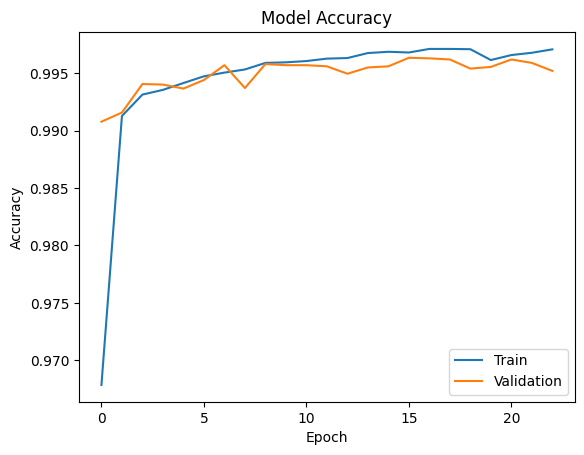

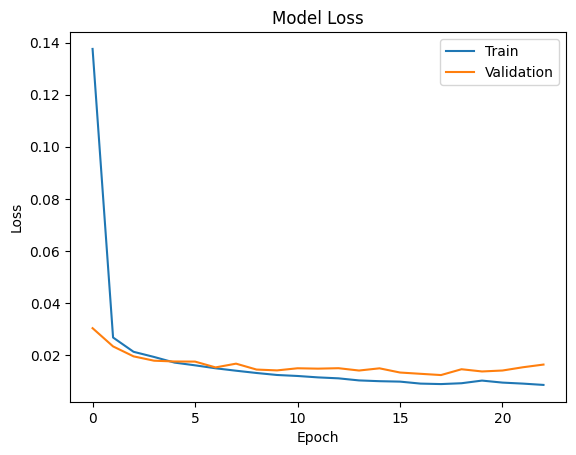

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert to predicted class
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Confusion Matrix:
[[ 9181     5     0     0]
 [    6 13436    18     9]
 [    1    32  2298     0]
 [    0    29     0   170]]

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       0.99      0.99      0.99      2331
         R2L       0.95      0.85      0.90       199

    accuracy                           1.00     25185
   macro avg       0.98      0.96      0.97     25185
weighted avg       1.00      1.00      1.00     25185



In [ ]:
import gradio as gr
def predict_intrusion(*features):

    # Convert inputs to DataFrame
    input_df = pd.DataFrame([features], columns=X.columns)

    # Scale features
    input_scaled = scaler.transform(input_df)
    input_scaled = input_scaled.astype(np.float32)

    # Reshape for LSTM
    input_lstm = input_scaled.reshape(1, 1, input_scaled.shape[1])

    # Predict
    prediction = model.predict(input_lstm)

    pred_class = np.argmax(prediction, axis=1)

    attack_type = le.inverse_transform(pred_class)

    confidence = float(np.max(prediction))

    return f"Prediction: {attack_type[0]} | Confidence: {confidence:.2f}"

In [ ]:
inputs = []

for feature in X.columns:
    inputs.append(gr.Number(label=feature, value=0))

In [ ]:
demo = gr.Interface(
    fn=predict_intrusion,
    inputs=inputs,
    outputs=gr.Textbox(label="Prediction"),
    title="Network Intrusion Detection System (LSTM)",
    description="Enter the network traffic features to classify the connection."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a97cf7314fe34c336.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
